In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.xls to Churn_Modelling.xls


In [ ]:
df = pd.read_csv('Churn_Modelling.xls')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.describe(include='object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


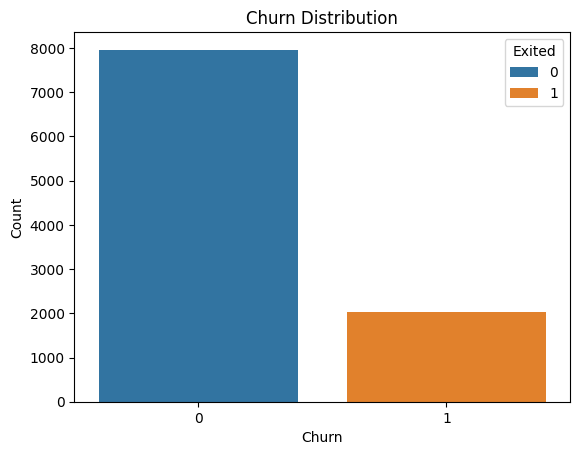

In [ ]:
sns.countplot(data=df, x='Exited', hue='Exited')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

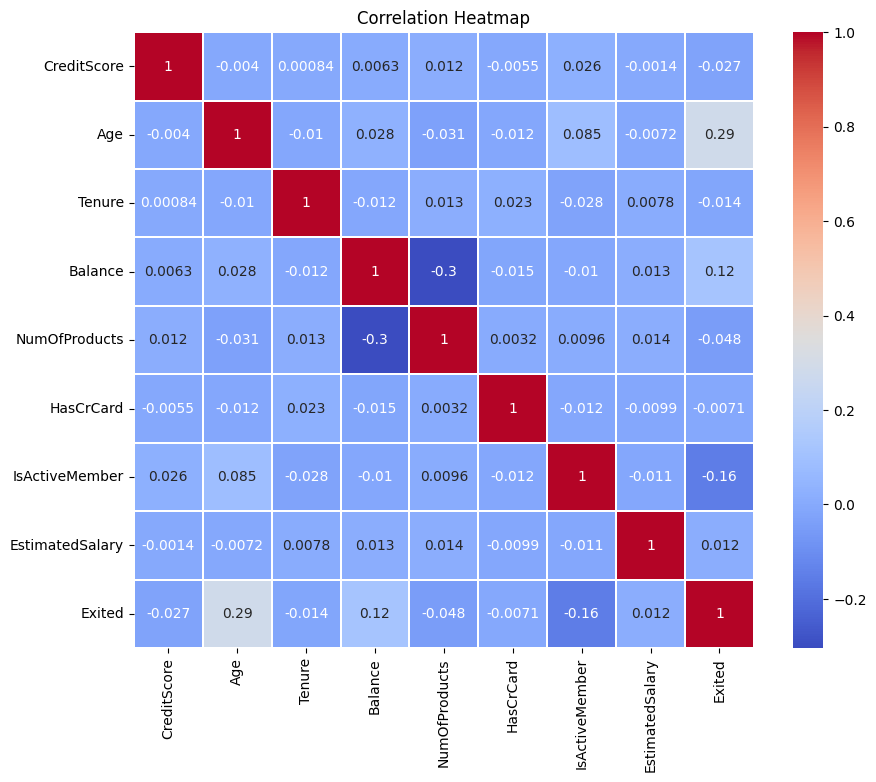

In [ ]:
numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm',linewidths=0.1 )
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
churn_counts = df['Exited'].value_counts()
churn_percent = churn_counts / churn_counts.sum() * 100
churn_percent.round()

,count
Exited,
0,80.0
1,20.0


In [ ]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [ ]:
numerical_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

In [ ]:
preprocessor = ColumnTransformer(transformers=
        [("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Apply random sampling to training data
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [ ]:
X_train_prep = preprocessor.fit_transform(X_train_ros)
X_test_prep = preprocessor.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=100, random_state=42)
rf.fit(X_train_prep, y_train_ros)

RandomForestClassifier(class_weight='balanced', max_depth=100, random_state=42)

In [ ]:
y_prediction = rf.predict(X_test_prep)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
acc = accuracy_score(y_test, y_prediction)
cr = classification_report(y_test, y_prediction)

In [ ]:
print("Accuracy Score - ", acc)
print("Classification Report -",cr)

Accuracy Score -  0.8615
Classification Report -               precision    recall  f1-score   support

           0       0.89      0.94      0.92      1607
           1       0.68      0.55      0.61       393

    accuracy                           0.86      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.85      0.86      0.86      2000



## Make a Prediction with User Input

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Define input widgets for each feature
credit_score_input = widgets.IntText(description='CreditScore:')
geography_input = widgets.Dropdown(options=['France', 'Germany', 'Spain'], description='Geography:')
gender_input = widgets.Dropdown(options=['Male', 'Female'], description='Gender:')
age_input = widgets.IntText(description='Age:')
tenure_input = widgets.IntText(description='Tenure:')
balance_input = widgets.FloatText(description='Balance:')
num_products_input = widgets.IntText(description='NumOfProducts:')
has_cr_card_input = widgets.Checkbox(description='HasCrCard:', value=True)
is_active_member_input = widgets.Checkbox(description='IsActiveMember:', value=True)
estimated_salary_input = widgets.FloatText(description='EstimatedSalary:')

predict_button = widgets.Button(description='Predict Churn')
output_widget = widgets.Output()

def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        # Create a DataFrame from the input values
        user_input_data = pd.DataFrame({
            'CreditScore': [credit_score_input.value],
            'Geography': [geography_input.value],
            'Gender': [gender_input.value],
            'Age': [age_input.value],
            'Tenure': [tenure_input.value],
            'Balance': [balance_input.value],
            'NumOfProducts': [num_products_input.value],
            'HasCrCard': [int(has_cr_card_input.value)], # Convert boolean to int
            'IsActiveMember': [int(is_active_member_input.value)], # Convert boolean to int
            'EstimatedSalary': [estimated_salary_input.value]
        })

        # Preprocess the user input
        user_input_prep = preprocessor.transform(user_input_data)

        # Make prediction
        prediction = rf.predict(user_input_prep)
        prediction_proba = rf.predict_proba(user_input_prep)

        if prediction[0] == 1:
            print(f"The customer is predicted to churn with a probability of {prediction_proba[0][1]:.2f}")
        else:
            print(f"The customer is predicted NOT to churn with a probability of {prediction_proba[0][0]:.2f}")

In [ ]:
predict_button.on_click(on_predict_button_clicked)

display(
    credit_score_input,
    geography_input,
    gender_input,
    age_input,
    tenure_input,
    balance_input,
    num_products_input,
    has_cr_card_input,
    is_active_member_input,
    estimated_salary_input,
    predict_button,
    output_widget
)

The customer is predicted NOT to churn with a probability of 0.90
